In [15]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path

# src 경로 등록 + config 로드
ROOT = Path.cwd().resolve()
if not (ROOT / "src").is_dir() and (ROOT.parent / "src").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from bootstrap import setup_notebook
concept_tag = "apple"
ROOT, cfg, _vars = setup_notebook(f"{concept_tag}.yaml") # target concept
globals().update(_vars)

import os
import json
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import torch
from diffusers import StableDiffusionPipeline

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


In [6]:
if "pipe" not in globals():
    pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5")
    pipe = pipe.to(DEVICE)
    pipe.safety_checker = None
    pipe.set_progress_bar_config(disable=True)


In [7]:
from load import load_cache
_cache = load_cache(cfg, "neuron_selection")
for k, v in _cache.items():
    globals()[k] = v
if hasattr(dino_embeds, 'numpy'):
    dino_embeds = dino_embeds.numpy()


cache loaded ← /project/dam/data/apple/up_blocks_1/_cache/neuron_selection.pt  keys=['ff_in', 'W2', 'b2', 'binary', 'pre_acts', 'sel', 'dino_embeds', 'gate_img', 'records', 'cand_idx', 'N_SELECT_PLANES', 'MAX_COMPARE_PLANES', 'MIN_REGION']


In [8]:
from load import load_images_and_ff_in
if "images" not in globals() or images is None:
    images, _, _ = load_images_and_ff_in(cfg)


# Injection

In [9]:
sel

[3930,
 2537,
 3592,
 4096,
 1284,
 2479,
 1083,
 4634,
 1343,
 2438,
 2966,
 2288,
 4347,
 626,
 1117,
 4415,
 861,
 3776,
 275,
 3043,
 4302,
 3545,
 2927,
 834,
 3620,
 813,
 4957,
 2474,
 1015,
 1195,
 2642,
 828,
 4690,
 118,
 1503,
 4942,
 673,
 1014,
 3063,
 2521,
 2328,
 48,
 1570,
 467,
 4432,
 3628,
 360,
 1205,
 4628,
 4985,
 3919,
 443,
 1936,
 3960,
 566,
 1780,
 2726,
 2748,
 3947,
 5031,
 1257,
 1411,
 4186,
 4924,
 214,
 3021,
 3973,
 535,
 3282,
 257,
 389,
 4592,
 4799,
 4590,
 321,
 1893,
 2888,
 2319,
 735,
 2353,
 3737,
 1693,
 1975,
 596,
 841,
 4314,
 3178,
 4961,
 1259,
 4949,
 2869,
 2448,
 4749,
 4427,
 3561,
 1861,
 748,
 4549,
 4794,
 5012,
 4782,
 1657,
 4576,
 816,
 1013,
 189,
 1609,
 3251,
 2219,
 2088,
 3763,
 290,
 2832,
 3171,
 482,
 2037,
 3612,
 4262,
 4275,
 316,
 2214,
 2750,
 2724,
 4812,
 3110,
 1025,
 5050,
 1045,
 4670,
 5060,
 2508,
 4221,
 4938,
 1138,
 1498,
 1307,
 2985,
 3846,
 1161,
 382,
 1454,
 371,
 4934,
 1865,
 2957,
 609,
 3768,
 1

In [25]:
# ── 단일 hyperplane 기준 concept_direction + INJECT_BLOCK steering ────────────
#   v3의 이미지 편집과 동일하되, concept group을 '한 평면(sel[0])의 부호'로 정의.
#   위 데이터 생성 코드와 상응: INJECT_BLOCK output에 alpha·d 를 가산해 편집.
import numpy as np, torch

STEER_PLANE = sel[2]

# ① INJECT_BLOCK 출력 활성 로드 (cell 9의 ff_in 로드와 동일 구조, "outputs" 키)
inject_list = []
for p_idx, prompt in enumerate(PROMPTS):
    pdir = resolve_pdir(p_idx, prompt)
    n    = NUM_IMAGES_PER_PROMPT
    data = torch.load(pdir / INJECT_BLOCK.replace(".", "_") / "activations.pt",
                      weights_only=True)
    inject_list.append(data["outputs"][:n].cpu().float())
inject_out = torch.cat(inject_list, dim=0)            # (N, C, H, W)
print(f"inject_out: {tuple(inject_out.shape)}")

# ② 한 평면의 부호로 두 그룹(+/-)을 나눠 평균 활성 차이 = concept_direction
plane_sign = binary[:, STEER_PLANE].cpu().numpy()     # (N,) in {0,1}
pos = np.where(plane_sign == 1)[0]
neg = np.where(plane_sign == 0)[0]
print(f"plane #{STEER_PLANE}:  (+) {len(pos)} imgs   (-) {len(neg)} imgs")

act_pos = inject_out[pos].mean(dim=0)                 # (C, H, W)
act_neg = inject_out[neg].mean(dim=0)
concept_direction = act_pos - act_neg                 # (+) 방향으로 미는 벡터
# concept_direction = concept_direction / concept_direction.norm()
print(f"concept_direction: {tuple(concept_direction.shape)}  "
      f"|d|={concept_direction.norm():.3f}")


# ③ steering hook & 생성 함수 (v3와 동일: INJECT_BLOCK output에 alpha_t·d 가산)
def _steering_delta_chw(d_np, step_idx, C, H, W):
    d = np.asarray(d_np, dtype=np.float32)
    if d.shape == (C, H, W):
        return d
    if d.ndim == 4 and d.shape[1:] == (C, H, W):
        return d[min(step_idx, d.shape[0] - 1)]
    raise ValueError(f"concept_direction {d.shape}, expected ({C},{H},{W})")


def _make_forward_steering_hook(direction, alpha, num_steps):
    d_np = np.asarray(direction, dtype=np.float32)
    step = [0]
    def _hook(_module, _inputs, output):
        out = output[0] if isinstance(output, tuple) else output
        si = step[0]; step[0] += 1
        _, C, H, W = out.shape
        dt = torch.as_tensor(_steering_delta_chw(d_np, si, C, H, W),
                             device=out.device, dtype=out.dtype)
        alpha_t = alpha * (1.0 - si / max(num_steps - 1, 1))   # step별 선형 감쇠
        new_out = out.clone()
        if new_out.shape[0] >= 2:        # classifier-free guidance: conditional만 편집
            new_out[1] = out[1] + alpha_t * dt
        else:
            new_out = out + alpha_t * dt
        return (new_out,) + tuple(output[1:]) if isinstance(output, tuple) else new_out
    return _hook


def generate_with_concept_direction(prompt, seed, direction, alpha, num_steps=None):
    n_steps = num_steps or NUM_INFERENCE_STEPS
    pipe.scheduler.set_timesteps(n_steps, device=DEVICE)
    actual_steps = len(pipe.scheduler.timesteps)
    blk = get_target_block(pipe.unet, INJECT_BLOCK)
    blk._forward_hooks.clear()
    handle = blk.register_forward_hook(
        _make_forward_steering_hook(direction, alpha, actual_steps))
    try:
        gen = torch.Generator(device="cpu").manual_seed(seed)
        with torch.inference_mode():
            result = pipe(prompt=prompt, negative_prompt=NEGATIVE_PROMPT,
                          num_inference_steps=n_steps, guidance_scale=GUIDANCE_SCALE,
                          generator=gen)
    finally:
        handle.remove()
    return result.images[0] if hasattr(result, "images") else result["images"][0]


inject_out: (100, 1280, 32, 32)
plane #3592:  (+) 39 imgs   (-) 61 imgs
concept_direction: (1280, 32, 32)  |d|=2618.225


plane #3592:  (+) 39 imgs   (-) 61 imgs


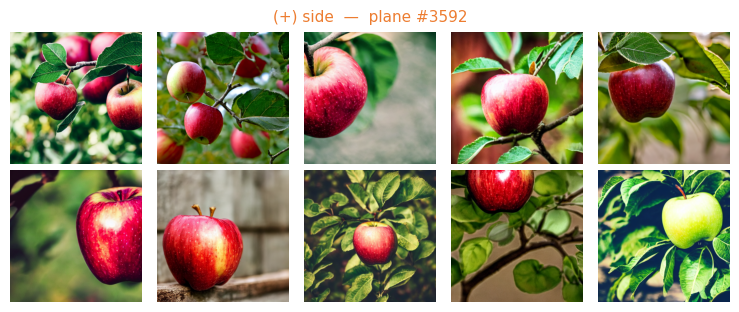

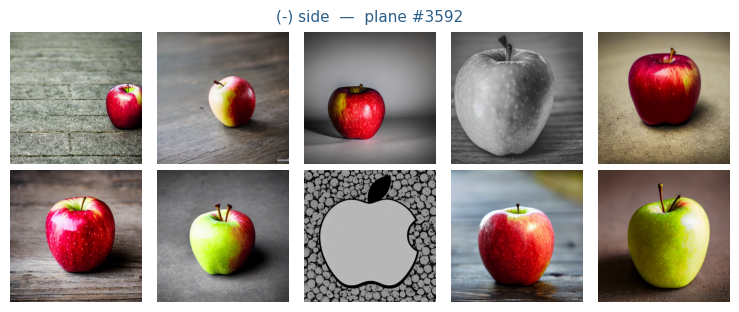

In [26]:
# ── STEER_PLANE 뉴런이 데이터셋을 어떤 기준으로 가르는지 확인 (+/- 그룹 미리보기) ──
#   부호거리(pre-GELU)로 정렬해 '가장 확실한' 양/음 그룹 이미지를 나열 → 의미 축 읽기
import numpy as np, matplotlib.pyplot as plt

N_SHOW = 10          # 각 그룹에서 보여줄 이미지 수
NCOLS  = 5

dist = (pre_acts[:, STEER_PLANE]).cpu().numpy()      # >0 → (+)그룹, <=0 → (-)그룹
n_pos, n_neg = int((dist > 0).sum()), int((dist <= 0).sum())
pos_idx = np.argsort(-dist)[:N_SHOW]                  # 가장 확실한 (+)부터
neg_idx = np.argsort( dist)[:N_SHOW]                  # 가장 확실한 (-)부터
print(f"plane #{STEER_PLANE}:  (+) {n_pos} imgs   (-) {n_neg} imgs")

for tag, idxs, n_tot, color in [
        (f'(+) side  —  plane #{STEER_PLANE}', pos_idx, n_pos, '#ed7d31'),
        (f'(-) side  —  plane #{STEER_PLANE}', neg_idx, n_neg, '#2C5F8A')]:
    n = len(idxs)
    nrows = (n + NCOLS - 1) // NCOLS
    fig, axes = plt.subplots(nrows, NCOLS, figsize=(1.5 * NCOLS, 1.7 * nrows),
                             squeeze=False)
    for k, ax in enumerate(axes.flat):
        if k < n:
            i = int(idxs[k])
            ax.imshow(np.array(images[i]))
            # ax.set_title(f'#{i}  ({dist[i]:+.1f})', fontsize=6)
        ax.axis('off')
    fig.suptitle(f'{tag}', #   —   most confident {n}/{n_tot}  (sorted by signed distance)',
                 fontsize=11, color=color, y=0.92) # , y=1.0
    plt.tight_layout(); plt.show()


In [ ]:
# ── steering: diverse prompts · original (5) | steered (5) ────────────────
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

TEST_PROMPTS = [
    'a photo of a orange',
    'a photo of a monkey',
    'a crayon drawing of a house by a child',
]
STEER_SEED_BASE = 1000
NUM_SEEDS       = 3
ALPHA_ORIG      = 0
ALPHA_STEER     = 2     # 편집 강도
SAVE_FIG        = True
FIG_DPI         = 200

FIG_BG = '#FFFFFF'
GRID   = '#CCCCCC'
TEXT   = '#222222'
MUTED  = '#666666'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica Neue', 'DejaVu Sans'],
    'text.color': TEXT,
    'figure.facecolor': FIG_BG,
    'axes.facecolor': FIG_BG,
})

seeds = list(range(STEER_SEED_BASE, STEER_SEED_BASE + NUM_SEEDS))
n_prompts = len(TEST_PROMPTS)

# ── generate: (prompt_idx, alpha, seed) ─────────────────────────────────────
grid_imgs = {}
total = n_prompts * len(seeds) * 2
done  = 0
for pi, prompt in enumerate(TEST_PROMPTS):
    for seed in seeds:
        for alpha in (ALPHA_ORIG, ALPHA_STEER):
            grid_imgs[(pi, alpha, seed)] = generate_with_concept_direction(
                prompt, seed, concept_direction, alpha)
            done += 1
            print(f"[{done}/{total}]  {prompt[:28]:28s}  a={alpha}  s={seed}", end='\r')
print('Generation complete.' + ' ' * 40)

Generation complete.                                        


saved: /project/dam/forGithub/analysis/results/apple/results_steering_multiprompt.png


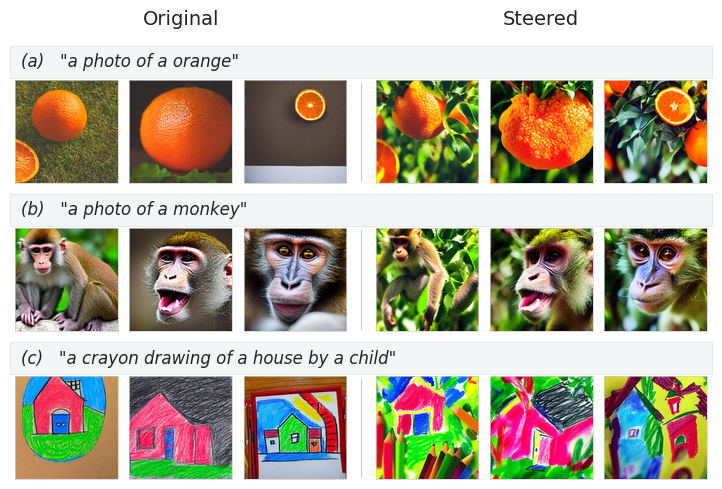

In [34]:
# ── layout ────────────────────────────────────────────────────────────────────
import textwrap
from matplotlib.patches import FancyBboxPatch

def _prompt_lines(pi, prompt, wrap=58):
    letter = chr(ord('a') + pi)
    quoted = f'"{prompt}"'
    if len(quoted) <= wrap:
        return f'({letter})   {quoted}'
    body = textwrap.fill(quoted, width=wrap, subsequent_indent=' ' * 7)
    return f'({letter})   {body}'

cell     = 1.14
prompt_h = 0.36   # inch per prompt ribbon
hdr_h    = 0.24
row_h    = prompt_h + cell
fig_w    = 2 * NUM_SEEDS * cell + 0.55
fig_h    = hdr_h + n_prompts * row_h + 0.22

fig = plt.figure(figsize=(fig_w, fig_h), facecolor=FIG_BG)
outer = GridSpec(
    1 + n_prompts, 1, figure=fig,
    height_ratios=[hdr_h / row_h] + [1.0] * n_prompts,
    hspace=0.10, left=0.04, right=0.99, top=0.97, bottom=0.03)

# ── global header: Original | Steered ─────────────────────────────────────────
hdr = outer[0].subgridspec(1, 2, wspace=0.055)
for bi, title in enumerate(('Original', 'Steered')):
    ax_h = fig.add_subplot(hdr[0, bi])
    ax_h.axis('off')
    ax_h.text(0.5, 0.72, title, ha='center', va='center',
              fontsize=14, color=TEXT, ) # fontweight='bold'
    pos = ax_h.get_position(fig)
    step = pos.width / NUM_SEEDS
    # for j in range(NUM_SEEDS):
    #     fig.text(pos.x0 + (j + 0.5) * step, pos.y0 + 0.006,
    #              str(j + 1), ha='center', va='bottom',
    #              fontsize=7.5, color=MUTED)

# ── per-prompt block ──────────────────────────────────────────────────────────
PROMPT_BG = '#F4F5F7'
PROMPT_BD = '#E2E5EA'

for pi, prompt in enumerate(TEST_PROMPTS):
    block = outer[pi + 1].subgridspec(
        2, 1, height_ratios=[prompt_h / cell, 1.0], hspace=0.03)

    # prompt ribbon
    ax_p = fig.add_subplot(block[0])
    ax_p.set_xlim(0, 1); ax_p.set_ylim(0, 1)
    ax_p.axis('off')
    panel = ax_p.get_position(fig)
    fig.add_artist(FancyBboxPatch(
        (panel.x0, panel.y0), panel.width, panel.height,
        boxstyle='square,pad=0', linewidth=0.6,
        edgecolor=PROMPT_BD, facecolor=PROMPT_BG,
        transform=fig.transFigure, clip_on=False, zorder=0))
    ax_p.text(
        0.015, 0.5, _prompt_lines(pi, prompt),
        ha='left', va='center', fontsize=12, color=TEXT,
        fontstyle='italic', linespacing=1.35, zorder=1)

    # image row: original | steered
    img_row = block[1].subgridspec(1, 2, wspace=0.055)
    for bi, alpha in enumerate((ALPHA_ORIG, ALPHA_STEER)):
        inner = img_row[0, bi].subgridspec(1, NUM_SEEDS, wspace=0.010)
        for j, seed in enumerate(seeds):
            ax = fig.add_subplot(inner[0, j])
            ax.imshow(np.asarray(grid_imgs[(pi, alpha, seed)]),
                      interpolation='lanczos')
            ax.set_xticks([]); ax.set_yticks([])
            for sp in ax.spines.values():
                sp.set_edgecolor(GRID)
                sp.set_linewidth(0.5)

    p_o = img_row[0, 0].get_position(fig)
    p_s = img_row[0, 1].get_position(fig)
    fig.add_artist(plt.Line2D(
        [(p_o.x1 + p_s.x0) / 2] * 2, [p_o.y0 + 0.004, p_o.y1 - 0.004],
        transform=fig.transFigure, color=GRID, lw=0.8, zorder=5))

from bootstrap import find_project_root

out_name = 'results_steering_multiprompt.png'
tag = globals().get('CONCEPT', globals().get('concept_tag', 'concept'))
RESULTS_DIR = find_project_root() / 'analysis' / 'results' / tag
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
save_path = (RESULTS_DIR / out_name).resolve()

if SAVE_FIG:
    fig.savefig(save_path, dpi=FIG_DPI, bbox_inches='tight',
                facecolor=FIG_BG, pad_inches=0.04)
    print(f'saved: {save_path}')
plt.show()